In [55]:
from langchain_core.messages import ToolMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("OPENAI_API_KEY") is None:
    raise ValueError("Please set OPENAI_API_KEY environment variable")
else:
    llm = ChatOpenAI(model="gpt-5-nano")
    # output = llm.invoke("I want to know the meaning of water").content
    print("OpenAI Key is set")

OpenAI Key is set


In [56]:
# Tool section

from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

from langchain.tools import tool

@tool
def get_personal_information(name: str) -> str:
    """"Use this tool to get personal information about Alice, Bob or Charlie, just provide their name as an input."""
    info = {
        "Alice": "Alice is a very nice person.",
        "Bob": "Bob is very clever.",
        "Charlie": "Charlie knows a lot of things."
    }
    return info.get(name, f"I don't know anything about {name}!")

@tool
def wiki_tool(query: str) -> str:
    """Use this tool to search Wikipedia for a query."""
    wiki_query = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wiki_query.invoke(query)


@tool
def arxiv_tool(query: str) -> str:
    """Use this tool to search ArXiv for a query."""
    arxiv_query = ArxivQueryRun(api_wrapper=ArxivAPIWrapper())
    return arxiv_query.invoke(query)


In [57]:
tools = [get_personal_information, wiki_tool, arxiv_tool]
llm_with_tools = llm.bind_tools(tools)

### Langgraph Creation

In [58]:
from typing import TypedDict, List
from langchain_core.prompts import ChatPromptTemplate

class GraphSchema(TypedDict):
    messages: List


In [59]:
def llm_node(state: GraphSchema) -> GraphSchema:
    messages = state["messages"]

    # Prompt template for the LLM
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant. Please respond to the user's question."),
            ("human", "{input}")
        ]
    )

    # chain
    chain = prompt | llm_with_tools
    response = chain.invoke({"input": messages})
    state["messages"] = messages + [response]

    return state

In [60]:
# custom tool node demo
from langchain_core.messages import ToolMessage

def tool_node(state: GraphSchema) -> GraphSchema:

    messages = state['messages']

    tools_by_name = {tool.name: tool for tool in tools}

    tool_results = []

    for tool_call in messages[-1].tool_calls:

        tool = tools_by_name[tool_call["name"]]

        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    # Update the state with the tool results
    state['messages'] = messages + tool_results

    return state


## Create conditional edge function

In [61]:
from langgraph.graph import StateGraph, START, END


def if_tool_call(state: GraphSchema) -> GraphSchema:
    messages = state["messages"]
    last_message = messages[-1]
    if not last_message.tool_calls:
        return END
    else:
        return "tool_node"

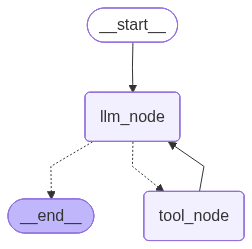

In [62]:
# Create state graph
react_graph = StateGraph(GraphSchema)

# Add nodes to the graph
react_graph.add_node("llm_node", llm_node)
react_graph.add_node("tool_node", tool_node)

# Add edges
react_graph.add_edge(START, "llm_node")
react_graph.add_conditional_edges("llm_node", if_tool_call, {"tool_node": "tool_node", END: END})
react_graph.add_edge("tool_node", "llm_node")
react_graph.add_edge("llm_node", END)

app = react_graph.compile()

from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))


In [63]:
# Graph invocation
app.invoke({"messages": [("human", "Get the personal information about Bob?") ]})

{'messages': [('human', 'Get the personal information about Bob?'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 217, 'prompt_tokens': 223, 'total_tokens': 440, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DBuLaxEAzUNXHjsZMpdBCmvyshbZo', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c835f-2a32-7193-bdfd-bec9cb10df63-0', tool_calls=[{'name': 'get_personal_information', 'args': {'name': 'Bob'}, 'id': 'call_9VcTbfgpAiqfznBzoD4x59xQ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 223, 'output_tokens': 217, 'total_tokens': 440, 'input_token_details': {'audio': 0, 'cache_read

In [68]:
# using stream
from langchain_core.messages import HumanMessage

for chunk in app.stream(
    {"messages": [HumanMessage(content="What is the top reasearch paper name on AI?")]},
    stream_mode="updates",
):
    print(chunk)

{'llm_node': {'messages': [HumanMessage(content='What is the top reasearch paper name on AI?', additional_kwargs={}, response_metadata={}), AIMessage(content='There isn’t a single “top” AI paper. AI is huge and has many subfields, so what’s considered the most influential depends on the area and era. Here are some landmark papers (historical and modern) that are widely cited and considered highly impactful across AI:\n\n- Attention Is All You Need (Vaswani et al., 2017) — Introduces the Transformer architecture, revolutionizing natural language processing and many other tasks.\n- ImageNet Classification with Deep Convolutional Neural Networks (Krizhevsky, Sutskever, Hinton, 2012) — AlexNet; sparked the deep learning revolution in computer vision.\n- Generative Adversarial Nets (Goodfellow et al., 2014) — Introduces GANs, a foundational idea in generative modeling.\n- Playing Atari with Deep Reinforcement Learning (Mnih et al., 2013) / Human-level control through deep reinforcement lear